Missing values:
 Airline          0
flight           0
source           0
stops            0
destination      0
class            0
price            0
duration         0
Duration_mins    0
dtype: int64


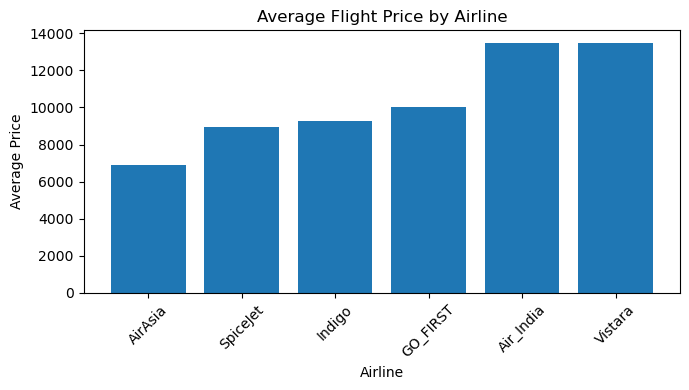

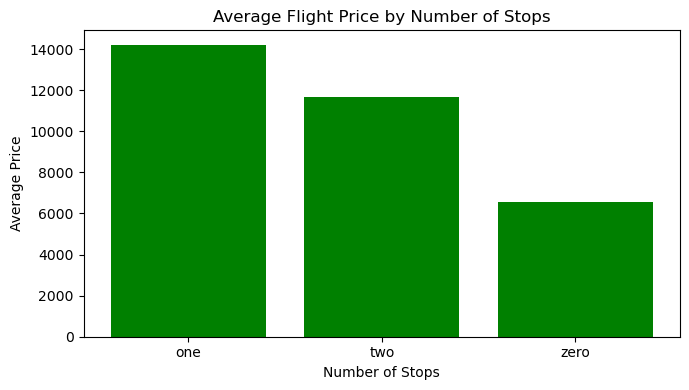

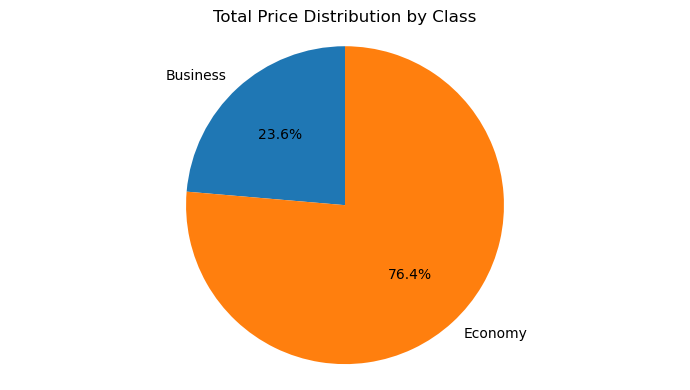

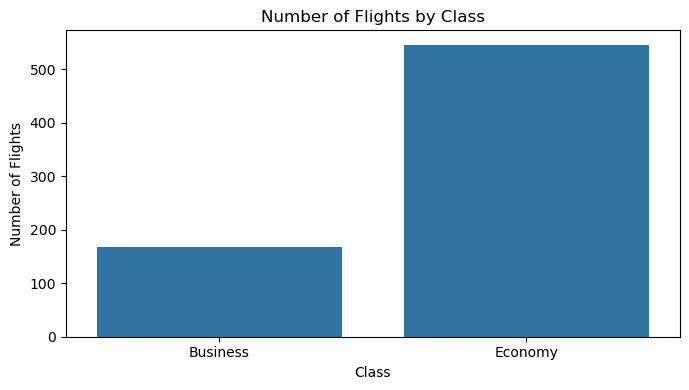

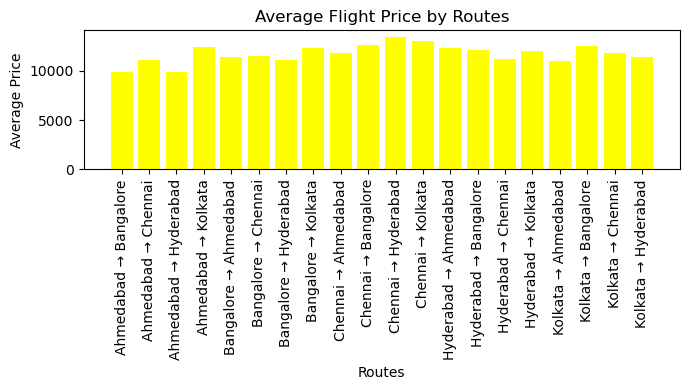

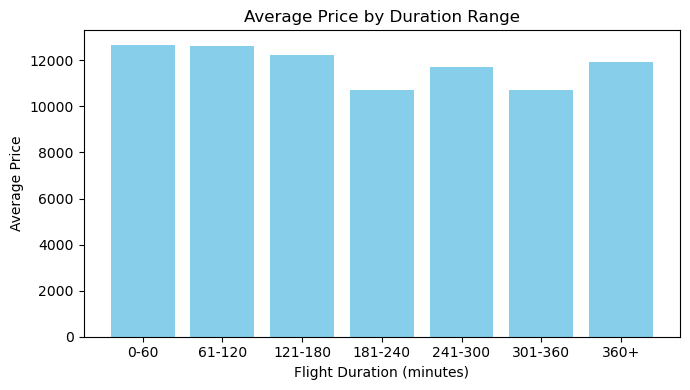


Before Tuning
R²: 0.3850933618962922
RMSE: 4436.698760071663


In [ ]:
#Flight Fare Prediction System 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# ---------------------- Load Data ----------------------
df = pd.read_csv("FlightData.csv", na_values=["###"])
df.columns = df.columns.str.strip()
# Keep original for visualization
df_original = df.copy()

# ---------------------- Handle Missing ----------------------
print("Missing values:\n", df.isnull().sum())

# ---------------------- Convert Duration ----------------------
def convert_duration_to_minutes(duration_str):
    try:
        parts = duration_str.split(':')
        hours = int(parts[0])
        minutes = int(parts[1])
        return hours * 60 + minutes
    except:
        return 0

df_original['Duration_mins'] = df_original['duration'].apply(convert_duration_to_minutes)
df['Duration_mins'] = df['duration'].apply(convert_duration_to_minutes)

# ---------------------- Feature Engineering ----------------------
# Stops
stops_mapping = {'zero': 0, 'one': 1, 'two': 2}
df['stops'] = df['stops'].map(stops_mapping)

# Class
class_mapping = {'Economy': 0, 'Business': 1}
df['class'] = df['class'].map(class_mapping)

# One-hot encode nominal features
df = pd.get_dummies(df, columns=['Airline', 'source', 'destination'], drop_first=True)

# ---------------------- Label Mapping for Visualization ----------------------
class_label_map = {0: 'Economy', 1: 'Business'}
df_original['class_label'] = df['class'].map(class_label_map)
df['class_readable'] = df['class'].map(class_label_map)

# ---------------------- Visualizations ----------------------
# Airline vs Price
airline_price = df_original.groupby('Airline')['price'].mean().sort_values()
plt.figure(figsize=(7, 4))
plt.bar(airline_price.index, airline_price.values)
plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.title("Average Flight Price by Airline")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Stops vs Price
stops_group = df_original.groupby('stops')['price'].mean()
plt.figure(figsize=(7,4))
plt.bar(stops_group.index.astype(str), stops_group.values, color="green")
plt.xlabel("Number of Stops")
plt.ylabel("Average Price")
plt.title("Average Flight Price by Number of Stops")
plt.tight_layout()
plt.show()

# Class vs Price Pie Chart
class_total_price = df_original.groupby('class_label')['price'].sum()
plt.figure(figsize=(7,4))
plt.pie(class_total_price.values, labels=class_total_price.index, autopct='%1.1f%%', startangle=90)
plt.title("Total Price Distribution by Class")
plt.axis('equal')
plt.tight_layout()
plt.show()

# Count Plot for Class
plt.figure(figsize=(7,4))
sns.countplot(x='class_readable', data=df)
plt.xlabel("Class")
plt.ylabel("Number of Flights")
plt.title("Number of Flights by Class")
plt.tight_layout()
plt.show()

# Route vs Price
df_original['route'] = df_original['source'].str.strip() + " → " + df_original['destination'].str.strip()
routes_group = df_original.groupby('route')['price'].mean()
plt.figure(figsize=(7,4))
plt.bar(routes_group.index, routes_group.values, color="yellow")
plt.xlabel("Routes")
plt.ylabel("Average Price")
plt.title("Average Flight Price by Routes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Duration Binning
max_duration = df_original['Duration_mins'].max()
last_bin = max(max_duration + 1, 361)
bins = [0, 60, 120, 180, 240, 300, 360, last_bin]
labels = ['0-60', '61-120', '121-180', '181-240', '241-300', '301-360', '360+']
df_original['Duration_Bin'] = pd.cut(df_original['Duration_mins'], bins=bins, labels=labels, include_lowest=True)
duration_price_group = df_original.groupby('Duration_Bin', observed=True)['price'].mean()
plt.figure(figsize=(7,4))
plt.bar(duration_price_group.index.astype(str), duration_price_group.values, color="skyblue")
plt.xlabel("Flight Duration (minutes)")
plt.ylabel("Average Price")
plt.title("Average Price by Duration Range")
plt.tight_layout()
plt.show()

# ---------------------- Model Training ----------------------
features = ['Duration_mins', 'stops', 'class'] + [
    col for col in df.columns if col.startswith(('Airline_', 'source_', 'destination_'))
]

X = df[features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------- Baseline Model ----------------------
rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train, y_train)

base_pred = rf_base.predict(X_test)

print("\nBefore Tuning")
print("R²:", r2_score(y_test, base_pred))
print("RMSE:", mean_squared_error(y_test, base_pred) ** 0.5)

# ---------------------- Grid Search Tuning ----------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)

# ---------------------- Save the trained model ----------------------
import joblib
joblib.dump(best_model, 'flight_fare_model.pkl')
print("\nTrained model saved as flight_fare_model.pkl")
# ---------------------- Evaluation After Tuning ----------------------
tuned_pred = best_model.predict(X_test)

print("\nAfter Tuning")
print("R²:", r2_score(y_test, tuned_pred))
print("RMSE:", mean_squared_error(y_test, base_pred) ** 0.5)

# ---------------------- User Input for Prediction ----------------------
print("\n--- Predict Flight Price from User Input ---")
duration = int(input("Enter Duration in minutes: "))
stops = int(input("Enter Number of Stops (0, 1, 2): "))
travel_class = int(input("Enter Class (0 = Economy, 1 = Business): "))

# Create dummy input with 0s for all one-hot encoded fields
user_input = dict.fromkeys(features, 0)
user_input['Duration_mins'] = duration
user_input['stops'] = stops
user_input['class'] = travel_class

# Ask for Airline, Source, Destination by name
all_columns = df.columns

for col in all_columns:
    if col.startswith("Airline_"):
        print(col.replace("Airline_", "Airline: "))

airline = input("Enter Airline name as shown above: ").strip()
user_input[f"Airline_{airline}"] = 1

for col in all_columns:
    if col.startswith("source_"):
        print(col.replace("source_", "Source: "))
source = input("Enter Source name as shown above: ").strip()
user_input[f"source_{source}"] = 1

for col in all_columns:
    if col.startswith("destination_"):
        print(col.replace("destination_", "Destination: "))

destination = input("Enter Destination name as shown above: ").strip()
user_input[f"destination_{destination}"] = 1

input_df = pd.DataFrame([user_input])
predicted_price = model.predict(input_df)[0]
print("\nPredicted Flight Price: Rs.", round(predicted_price, 2))
